<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/VAE_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - kl_loss: 5.4053 - loss: 168.9328 - reconstruction_loss: 163.5276
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - kl_loss: 5.0770 - loss: 162.1962 - reconstruction_loss: 157.1192
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - kl_loss: 4.4233 - loss: 168.7597 - reconstruction_loss: 164.3363
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - kl_loss: 4.3278 - loss: 174.2245 - reconstruction_loss: 169.8967
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 5.1686 - loss: 153.4481 - reconstruction_loss: 148.2795
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


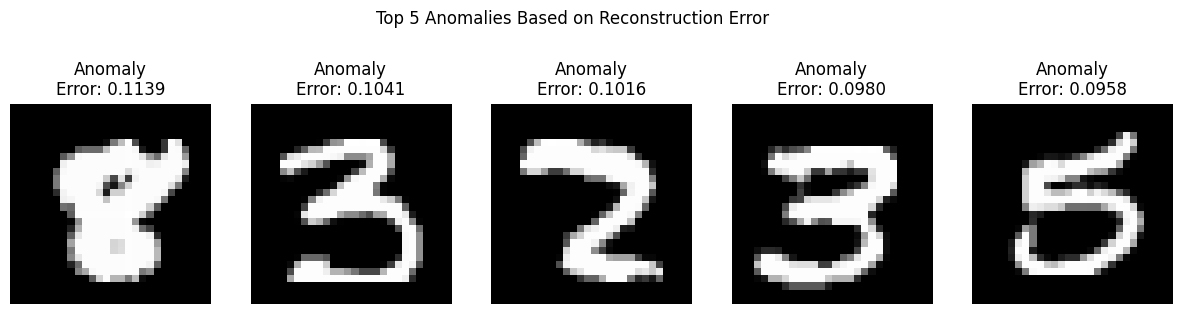

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# --- 1. DATA PREPARATION ---
# Load MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
# Normalize and expand dimensions for the model
all_digits = np.concatenate([x_train, x_test], axis=0).astype("float32") / 255.0
all_digits = np.expand_dims(all_digits, -1)

# --- 2. VAE ARCHITECTURE ---
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 2

# Encoder
encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x) # Required hidden layer
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs) # Required hidden layer
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(decoder_outputs)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# --- 3. VAE MODEL DEFINITION ---
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

# --- 4. TRAINING ---
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
# Training for 5 epochs for speed; increase to 10-20 for better results
vae.fit(all_digits, epochs=5, batch_size=128)

# --- 5. ANOMALY VISUALIZATION ---
# Select a subset to test for anomalies
test_subset = all_digits[:1000]
_, _, z_test = vae.encoder.predict(test_subset)
reconstructed_test = vae.decoder.predict(z_test)

# Calculate MSE error per image
errors = np.mean(np.square(test_subset - reconstructed_test), axis=(1, 2, 3))

# Sort and get top 5 anomalies
anomaly_indices = np.argsort(errors)[::-1][:5]

# Plotting
plt.figure(figsize=(15, 4))
for i, idx in enumerate(anomaly_indices):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(test_subset[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Anomaly\nError: {errors[idx]:.4f}")
    plt.axis("off")

plt.suptitle("Top 5 Anomalies Based on Reconstruction Error")
plt.show()